# k-Nearest Neighbors regression on Auto MPG

This tutorial uses pandas and scikit-learn to predict a car's fuel economy (`mpg`) from its characteristics. It uses a direct `KNeighborsRegressor` with `k = 3`, without a pipeline or grid search.

By the end, you will be able to clean the data, visualize two variables, split and scale the observations, fit a k-NN regression model, evaluate its predictions, and estimate MPG for a new car.

## Outline

1. Read and inspect the dataset
2. Clean invalid and missing values
3. Visualize weight and MPG
4. Prepare and split the data
5. Scale the features and train with `k = 3`
6. Evaluate the predictions
7. Predict the MPG of a new car

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## 1. Read and inspect the dataset

The notebook is in `knn/`, so pandas reads the CSV from `../dataset/autoMpg.csv`. The file uses `?` for missing horsepower values.

In [2]:
cars = pd.read_csv("../dataset/autoMpg.csv", na_values="?")

print(f"Dataset shape: {cars.shape}")
cars.head()

Dataset shape: (398, 8)


,cylinders,displacement,horsepower,weight,acceleration,model,origin,mpg
0,8,307.0,130.0,3504,12.0,70,1,18.0
1,8,350.0,165.0,3693,11.5,70,1,15.0
2,8,318.0,150.0,3436,11.0,70,1,18.0
3,8,304.0,150.0,3433,12.0,70,1,16.0
4,8,302.0,140.0,3449,10.5,70,1,17.0


In [3]:
print("Column types:")
print(cars.dtypes)
print("\nMissing values:")
print(cars.isna().sum())
print(f"\nMPG range: {cars['mpg'].min()} to {cars['mpg'].max()}")

Column types:
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model             int64
origin            int64
mpg             float64
dtype: object

Missing values:
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model           0
origin          0
mpg             0
dtype: int64

MPG range: 9.0 to 270.0


## 2. Clean the data

Convert `horsepower` to numeric and remove rows with missing values. The dataset also contains one implausible value of `mpg = 270`; instead of guessing its intended value, remove observations outside the reasonable interval 0–100 MPG.

In [4]:
cars["horsepower"] = pd.to_numeric(cars["horsepower"], errors="coerce")

rows_before = len(cars)
cars = cars.dropna().copy()
cars = cars[cars["mpg"].between(0, 100)].copy()

print(f"Removed rows: {rows_before - len(cars)}")
print(f"Clean dataset shape: {cars.shape}")

Removed rows: 7
Clean dataset shape: (391, 8)


## 3. Visualize two features

The plot compares vehicle weight with fuel economy. Color and marker shape identify the car's origin.

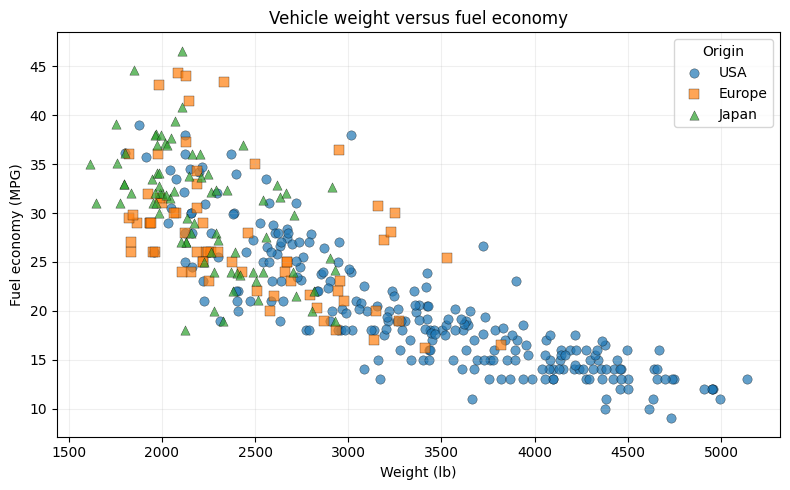

In [5]:
origin_styles = {
    1: {"label": "USA", "color": "tab:blue", "marker": "o"},
    2: {"label": "Europe", "color": "tab:orange", "marker": "s"},
    3: {"label": "Japan", "color": "tab:green", "marker": "^"},
}

plt.figure(figsize=(8, 5))
for origin, style in origin_styles.items():
    origin_data = cars[cars["origin"] == origin]
    plt.scatter(
        origin_data["weight"],
        origin_data["mpg"],
        label=style["label"],
        color=style["color"],
        marker=style["marker"],
        s=45,
        alpha=0.7,
        edgecolors="black",
        linewidths=0.3,
    )

plt.xlabel("Weight (lb)")
plt.ylabel("Fuel economy (MPG)")
plt.title("Vehicle weight versus fuel economy")
plt.legend(title="Origin")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 4. Prepare and split the data

The seven car characteristics are the input features. `mpg` is the continuous target. Here, `model` means model year, from 70 through 82.

In [6]:
FEATURES = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model",
    "origin",
]
TARGET = "mpg"

X = cars[FEATURES]
y = cars[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

Training observations: 312
Test observations: 79


## 5. Scale the features and train the regressor

k-NN uses distances, so the inputs must have comparable scales. Fit the scaler only on the training set, transform both sets, and train with `k = 3`.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = KNeighborsRegressor(n_neighbors=3)
model.fit(X_train_scaled, y_train)

print("Regressor trained with k = 3")

Regressor trained with k = 3


## 6. Evaluate the predictions

MAE and RMSE are prediction errors measured in MPG, so lower is better. The R² score measures how much variation the model explains; values closer to 1 are better.

In [8]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean absolute error: {mae:.3f} MPG")
print(f"Root mean squared error: {rmse:.3f} MPG")
print(f"R-squared: {r2:.3f}")

Mean absolute error: 2.235 MPG
Root mean squared error: 3.131 MPG
R-squared: 0.820


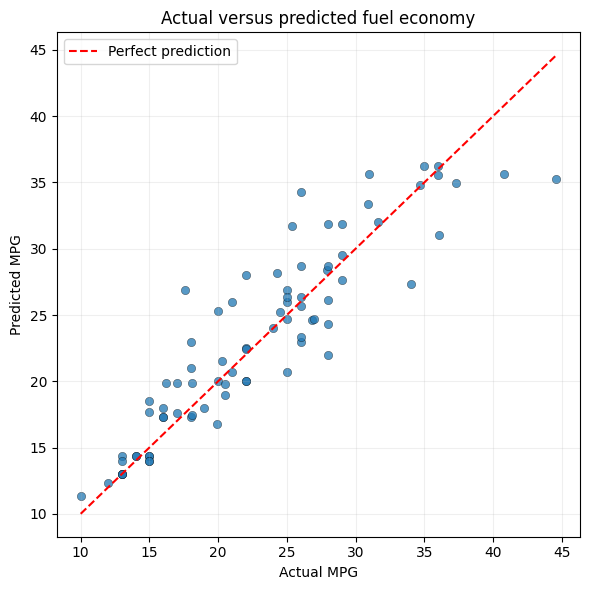

In [12]:
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolors="black", linewidths=0.3)
plt.plot([minimum, maximum], [minimum, maximum], "r--", label="Perfect prediction")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual versus predicted fuel economy")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Predict a new car

Create a DataFrame with the same feature names and units, scale it with the already fitted scaler, and ask the model for its MPG estimate.

In [10]:
new_car = pd.DataFrame(
    [[4, 120, 88, 2500, 16.0, 80, 2]],
    columns=FEATURES,
)

new_car_scaled = scaler.transform(new_car)
predicted_mpg = model.predict(new_car_scaled)[0]

print(f"Predicted fuel economy: {predicted_mpg:.1f} MPG")

Predicted fuel economy: 36.3 MPG
